In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

def line_id_color(line_id, T, cm):
    if line_id < 0:
        return 'red' 
    return cm(line_id / T)

def visualize_confidence(results):
    if results is None:
        print("No corridor results to visualize.")
        return
    
    max_len = max(len(r["confidence"]) for r in results)
    C = np.full((len(results), max_len), np.nan)

    for i, r in enumerate(results):
        C[i, :len(r["confidence"])] = r["confidence"]

    plt.figure(figsize=(16, 16))
    plt.imshow(C, aspect="auto", cmap="inferno")
    plt.colorbar(label="confidence")
    plt.xlabel("pseudotime")
    plt.ylabel("corridor")
    plt.title("Confidence heatmap")
    plt.show()

def visualize_template(template):
    if template is None:
        print("No template to visualize.")
        return
    plt.figure(figsize=(8, 3))
    plt.plot(template, marker="o")
    plt.title("Canonical period template")
    plt.xlabel("Line ID")
    plt.ylabel("Signal value")
    plt.grid(True)
    plt.show()

def visualize_overlay(
    img,
    corridor_bbox,
    results,
    T,
    m,
    alpha_scale=0.8,
    show_ids=False,
    figsize=(16, 16),
    DF=None,
):
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(img, cmap="gray")
    ax.set_title("Corridor line IDs and periods")
    ax.axis("off")
    cmap = plt.get_cmap("turbo", T)
    colors = ["red", "blue"]
    period_idx = 0

    

    for res in results:
        bbox = res["bbox"]
        x0, x1 = bbox["x0"], bbox["x1"]
        y0, y1 = bbox["y0"], bbox["y1"]

        signal = res["signal"]
        line_id = bbox["line_id"]
        conf = res["confidence"]

        xs = list(range(x0, x1 + 1, m))
        period_start_x = None
        period_top = None
        period_bottom = None


        for i, x in enumerate(xs):
            
            if i >= len(line_id):
                break

            lid = line_id[i] 
            c = conf[i]

            
            color = line_id_color(lid, T, cmap)
            alpha = alpha_scale * 1

            col = img[y0:y1+1, x]
            if np.all(col == 0):
                continue
            ys = np.flatnonzero(col)
            y_top = y0 + int(ys[0])
            y_bottom = y0 + int(ys[-1])


            if lid == 0:
                period_start_x = x
                period_top = y_top
                period_bottom = y_bottom

            elif lid == T - 1 and period_start_x is not None:
                width = x - period_start_x
                height = period_bottom - period_top

                col = colors[period_idx % 2]

                rect = Rectangle(
                    (period_start_x, period_top),  # bottom-left corner
                    width,
                    height,
                    linewidth=1,
                    edgecolor=col,
                    facecolor=col,
                    alpha=0.5
                )

                plt.gca().add_patch(rect)
                period_idx += 1

            ax.plot([x, x], [y_top, y_bottom],
                    color=color, alpha=alpha, linewidth=1)

        # draw bbox
        plt.plot([x0, x1], [y0, y0], color='red', linewidth=0.5)
        plt.plot([x0, x1], [y1, y1], color='red', linewidth=0.5)
        plt.plot([x0, x0], [y0, y1], color='red', linewidth=0.5)
        plt.plot([x1, x1], [y0, y1], color='red', linewidth=0.5)
    
    plt.show()


In [3]:
from tifffile import imread
from morphology_pipeline.segmentation.stain_dataset import StainDataset

background = r'..\test_1462.tif'
img = imread(background)
img = img[..., :3]
folder = r'..\Chip_1462_1_real'

SD = StainDataset.from_folder(folder)
SD.dataframe.index


Areas: [89678   322] for obj 1
Areas: [89834   166] for obj 2
Areas: [89724   276] for obj 3
Areas: [89737   263] for obj 4
Areas: [89779   221] for obj 5
Areas: [89786   214] for obj 6
Areas: [89520   233   247] for obj 7
Areas: [89485   254   261] for obj 8
Areas: [89516   252   232] for obj 9
Areas: [89772   228] for obj 10
Areas: [89866     1   133] for obj 11
Areas: [89759   241] for obj 12
Areas: [89736   218    46] for obj 13
Areas: [90000] for obj 14
Areas: [90000] for obj 15
Areas: [89837   163] for obj 16
Areas: [89835   165] for obj 17
Areas: [89813     7   180] for obj 18
Areas: [89819   181] for obj 19
Areas: [89733   267] for obj 21
Areas: [89977    23] for obj 22
Areas: [89866   134] for obj 23
Areas: [89705   295] for obj 24
Areas: [89742   258] for obj 25
Areas: [89722   278] for obj 26
Areas: [89724   276] for obj 27
Areas: [89779   221] for obj 28
Areas: [89691   309] for obj 29
Areas: [89733   267] for obj 30
Areas: [89707   293] for obj 31
Areas: [89448   331   221

Index([          10001,           20001,           30001,           40001,
                 50001,           60001,           70001,           80001,
                 90001,          100001,
       ...
           64700010002,     64900010002,     65200010002,     67500010002,
           68900010002,  48000100020003, 453000100020003, 457000100020003,
       470000100020003, 521000100020003],
      dtype='int64', name='obj_id', length=675)

In [4]:

SD.add_all_data()
SD.dataframe


c:\Users\dmitr\Documents\Projects Coding\Nikita PhD\morphology_pipeline\.venv\lib\site-packages\cp_measure\core\measureobjectintensitydistribution.py:279: RuntimeWarning: invalid value encountered in divide
  radial_means = numpy.ma.masked_array(radial_values / pixel_count, mask)


,path_background,path_dapi,path_yap,path_actin,height,width,channels,radial_distribution.RadialDistribution_FracAtD_1of4,radial_distribution.RadialDistribution_MeanFrac_1of4,radial_distribution.RadialDistribution_RadialCV_1of4,...,granularity.Granularity_7,granularity.Granularity_8,granularity.Granularity_9,granularity.Granularity_10,granularity.Granularity_11,granularity.Granularity_12,granularity.Granularity_13,granularity.Granularity_14,granularity.Granularity_15,granularity.Granularity_16
obj_id,,,,,,,,,,,,,,,,,,,,,
10001,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.320611,8.603053,0.293314,...,26.056697,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
20001,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.272553,5.027085,0.366094,...,100.000000,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
30001,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.171021,5.244656,0.419590,...,100.000000,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
40001,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.165913,4.848332,0.433454,...,27.770320,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
50001,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.519174,12.748607,0.539141,...,100.000000,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48000100020003,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.098837,2.648837,0.302872,...,100.000000,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
453000100020003,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.161863,3.329743,0.439287,...,100.000000,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
457000100020003,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.016863,0.215008,0.027109,...,100.000000,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0


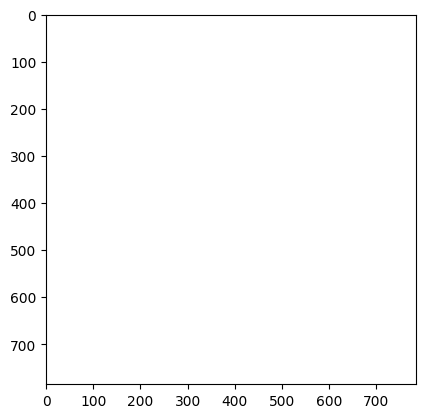

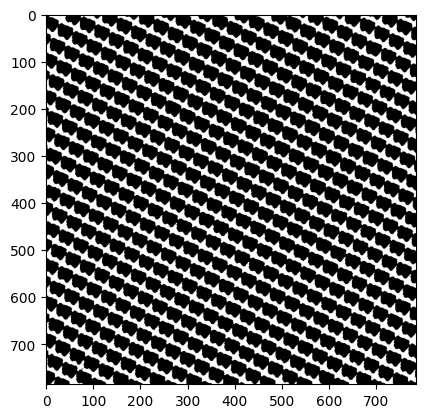

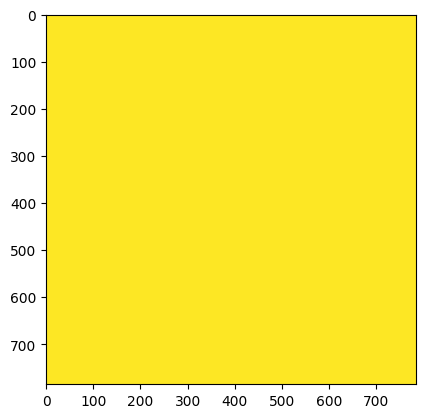

Deskewed by 28.34 degrees.
Detected 31 corridors.


,path_background,path_dapi,path_yap,path_actin,height,width,channels,radial_distribution.RadialDistribution_FracAtD_1of4,radial_distribution.RadialDistribution_MeanFrac_1of4,radial_distribution.RadialDistribution_RadialCV_1of4,...,granularity.Granularity_7,granularity.Granularity_8,granularity.Granularity_9,granularity.Granularity_10,granularity.Granularity_11,granularity.Granularity_12,granularity.Granularity_13,granularity.Granularity_14,granularity.Granularity_15,granularity.Granularity_16
obj_id,,,,,,,,,,,,,,,,,,,,,
10001,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.320611,8.603053,0.293314,...,26.056697,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
20001,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.272553,5.027085,0.366094,...,100.000000,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
30001,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.171021,5.244656,0.419590,...,100.000000,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
40001,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.165913,4.848332,0.433454,...,27.770320,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
50001,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.519174,12.748607,0.539141,...,100.000000,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48000100020003,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.098837,2.648837,0.302872,...,100.000000,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
453000100020003,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.161863,3.329743,0.439287,...,100.000000,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
457000100020003,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.016863,0.215008,0.027109,...,100.000000,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0


In [6]:
import importlib
import morphology_pipeline.dataset_creator as dataset_creator
import morphology_pipeline.pseudotime as pseudotime
import morphology_pipeline.corridor_mask as corridor_mask
import morphology_pipeline.segmentation.stain_dataset as StainDataset

importlib.reload(StainDataset)
importlib.reload(dataset_creator)
importlib.reload(pseudotime)
importlib.reload(corridor_mask)


pt, corridors, corr_mask = dataset_creator.create_dataset(img, folder, SD)

SD.dataframe


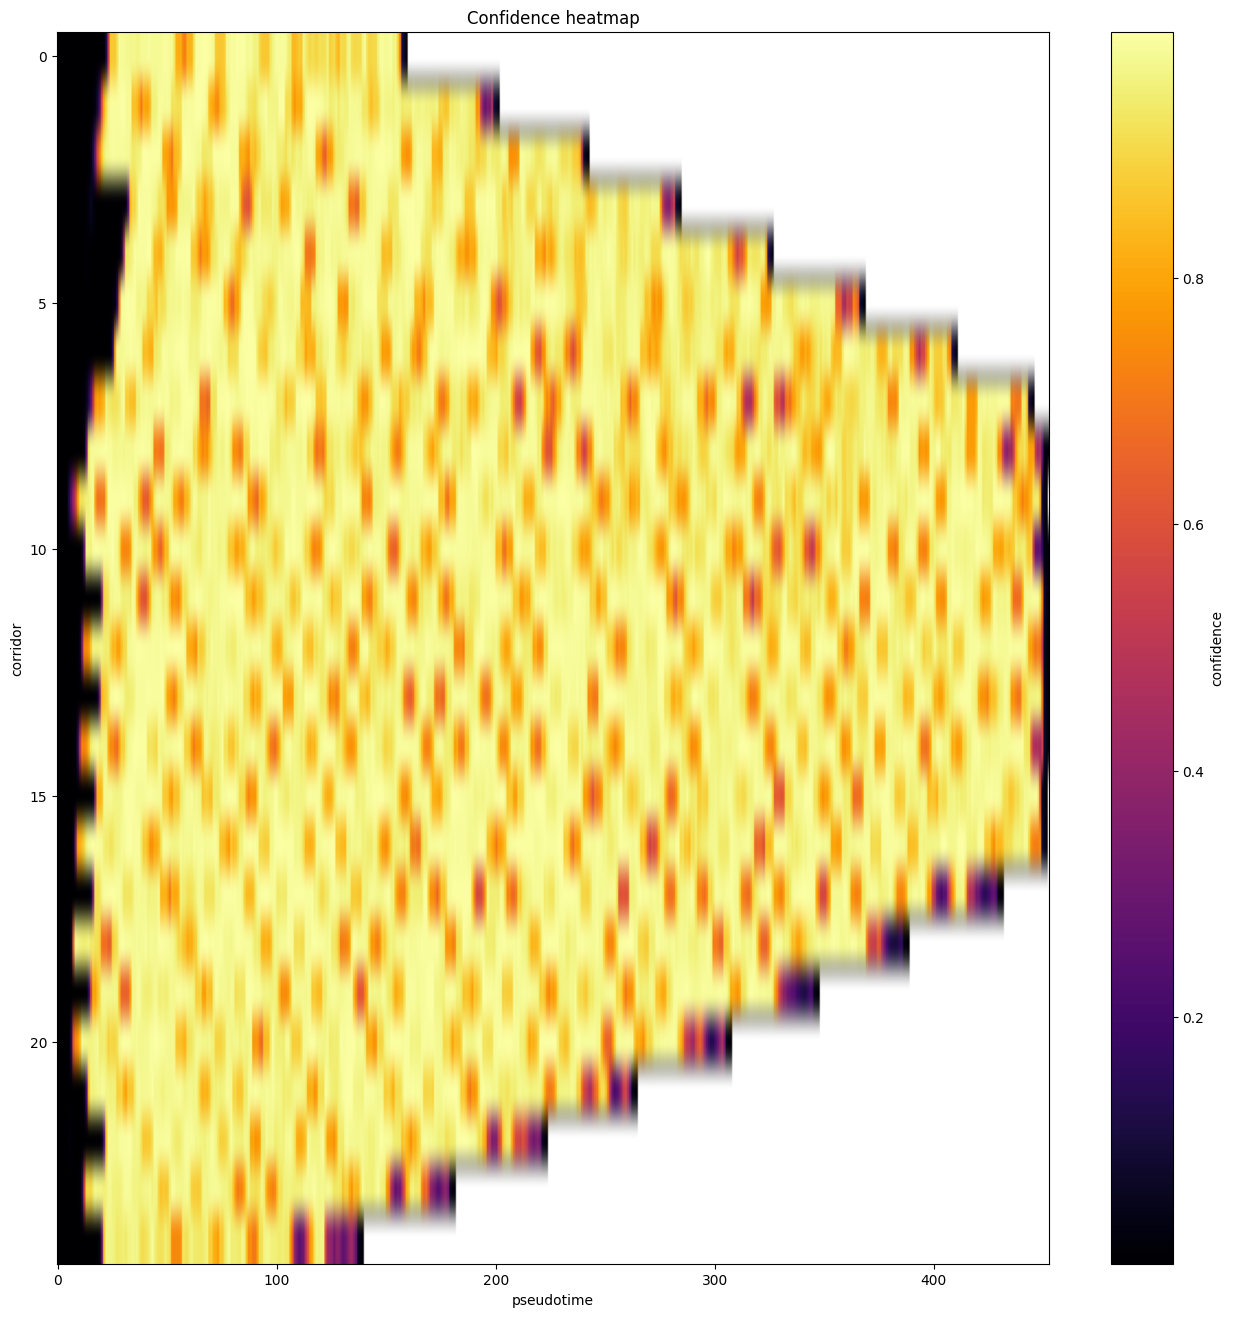

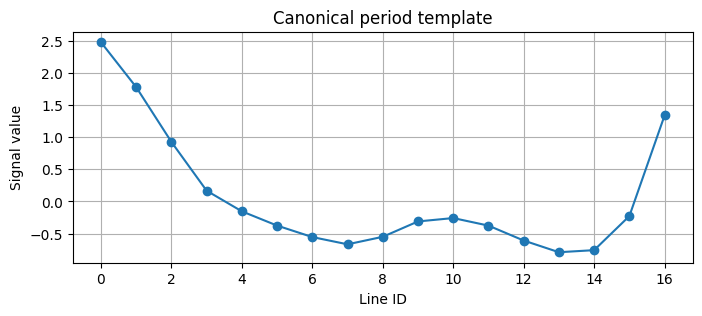

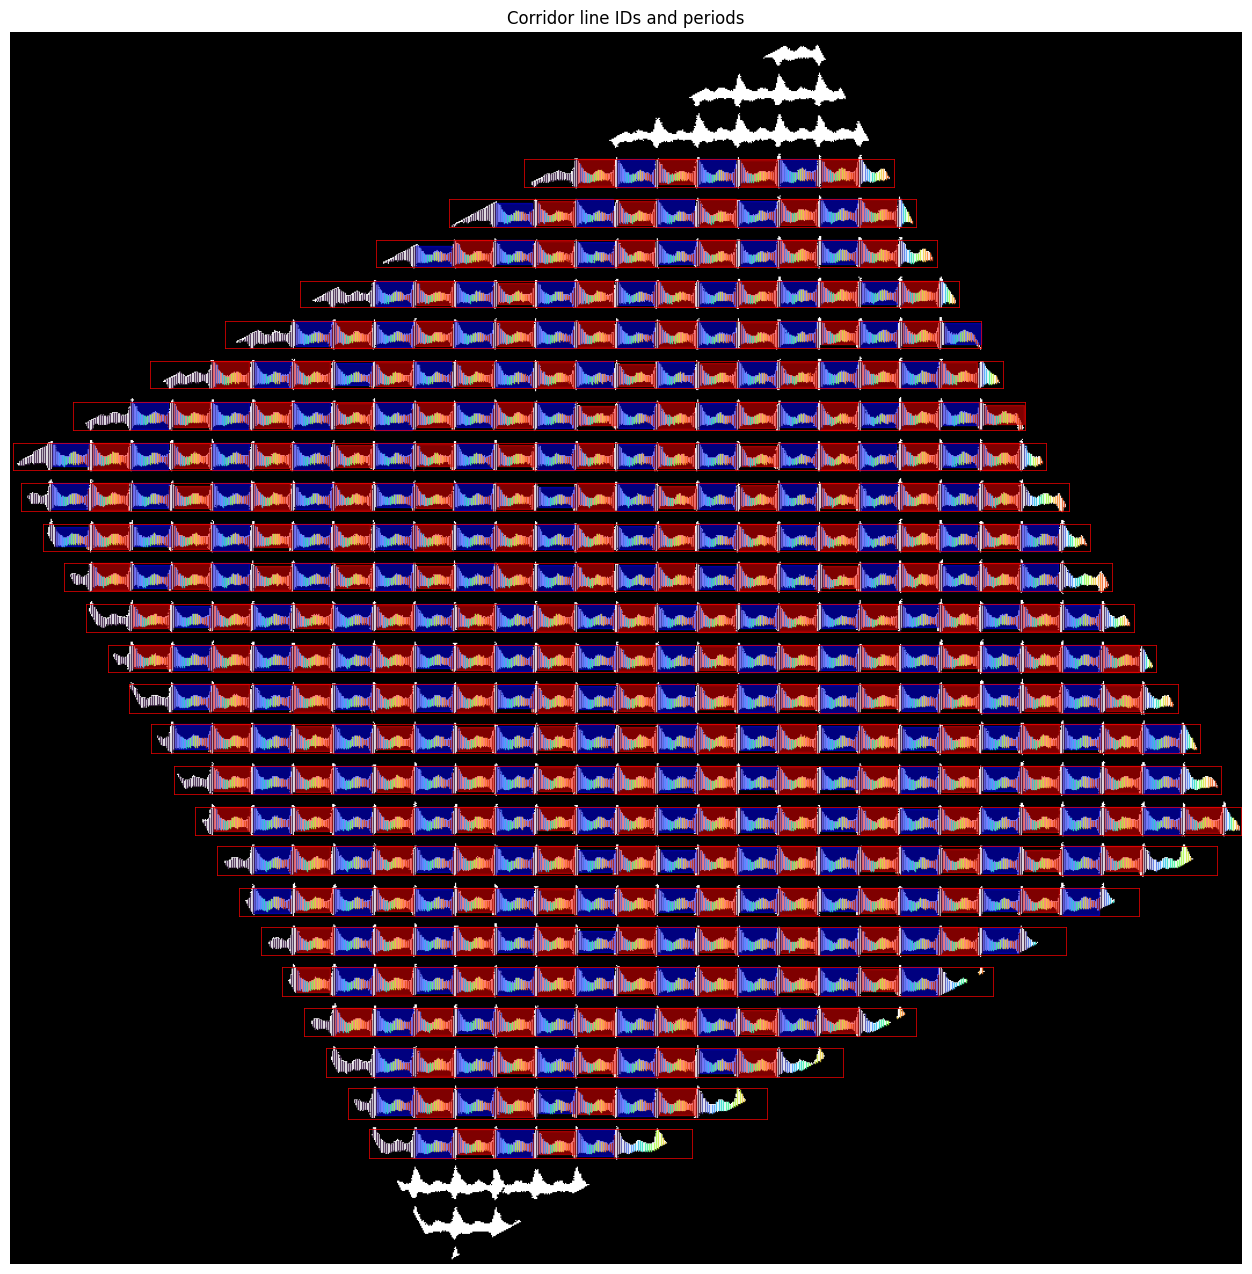

17


In [11]:
visualize_confidence(pt["corridors"])
visualize_template(pt["template"])
visualize_overlay(
    img=corr_mask,
    corridor_bbox=corridors,
    results=pt["corridors"],
    T=pt["period"],
    m=2,
    show_ids=False,
    DF=SD.dataframe,
)
print(pt['period'])

In [71]:
SD.dataframe.loc[0]["path_dapi"]

nan

C:\Users\dmitr\AppData\Local\Temp\ipykernel_15856\2767544448.py:96: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap("tab20", max_rows)


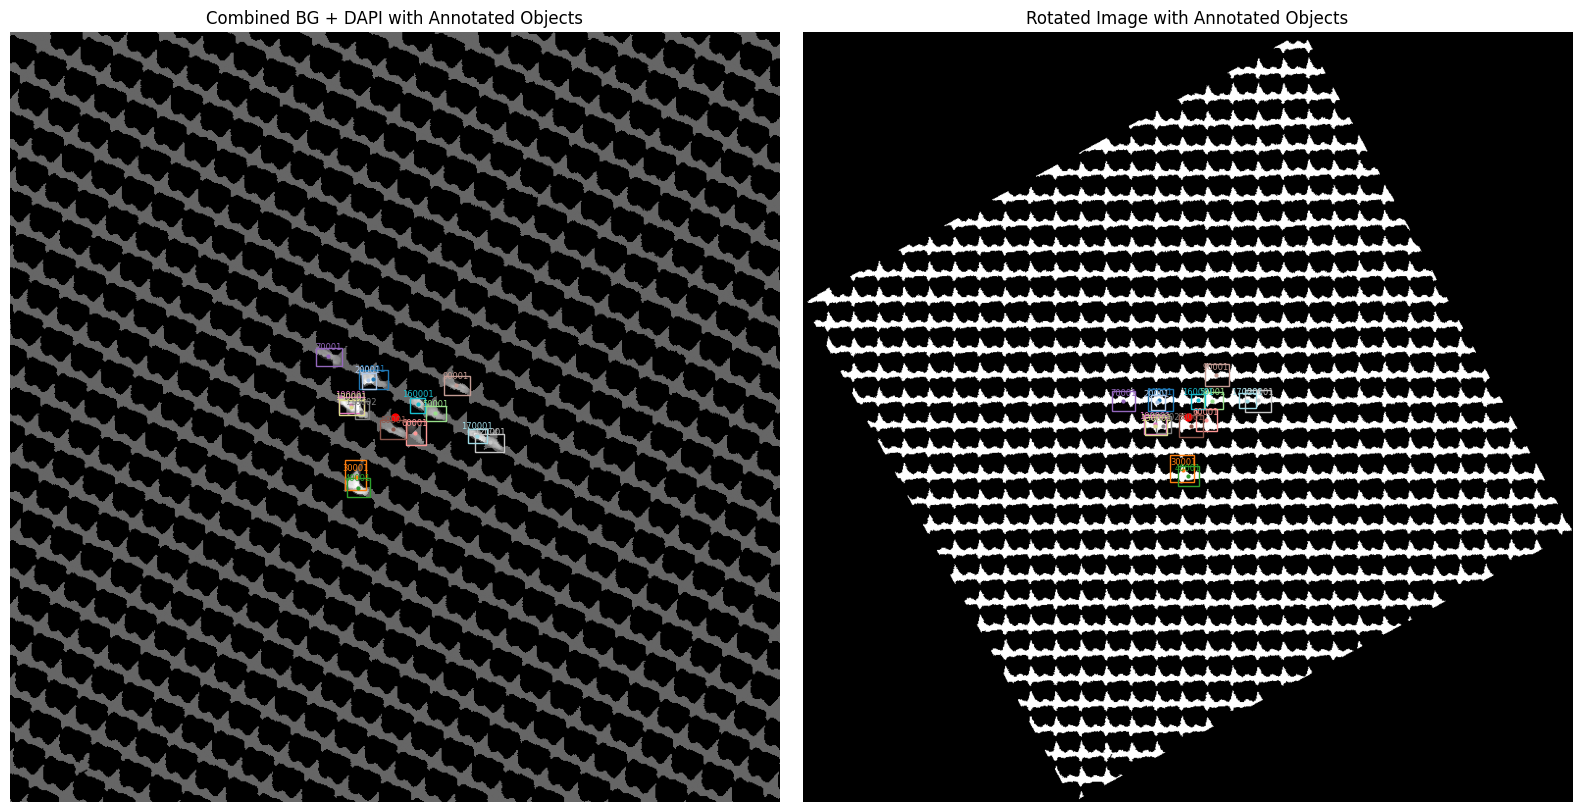

In [12]:

from skimage.io import imread
import matplotlib.cm as cm

def rotation_viz_with_dapi(
    BG, rotated, SD, blend_mode="add", alpha=0.5,
    max_rows=30, dot_size=3
):
    DF = SD.dataframe

    BG = BG.astype(np.float32)
    RW, RH = rotated.shape[:2]
    cry = (RW - 1) / 2
    crx = (RH - 1) / 2

    # --- 1. Build a composite DAPI image ---
    dapi_stack = []
    for idx, row in DF.iloc[:max_rows].iterrows():
        try:
            path = row["path_dapi"]
            dapi_img = imread(path)
        except Exception as e:
            print(f"Could not read DAPI image for row {idx}: {e}")
            continue

        H, W = BG.shape[:2]
        h2, w2 = dapi_img.shape[:2]

        cy_big = (H - 1) / 2
        cx_big = (W - 1) / 2

        cy_small = (h2 - 1) / 2
        cx_small = (w2 - 1) / 2

        x0 = int(round(cx_big - cx_small))
        y0 = int(round(cy_big - cy_small))

        canvas = np.zeros((H, W), dtype=float)
        #canvas = np.zeros((H, W, 2), dtype=float)

        # Destination slice (big image)
        y1 = max(0, y0)
        x1 = max(0, x0)
        y2 = min(H, y0 + h2)
        x2 = min(W, x0 + w2)

        # Corresponding source slice (small image)
        sy1 = y1 - y0
        sx1 = x1 - x0
        sy2 = sy1 + (y2 - y1)
        sx2 = sx1 + (x2 - x1)

        # Write intensity
        #canvas[y1:y2, x1:x2, 0] = dapi_img[sy1:sy2, sx1:sx2]

        # Write alpha (fully opaque where image exists)
        #canvas[y1:y2, x1:x2, 1] = 1.0

        canvas[y1:y2, x1:x2] = dapi_img[sy1:sy2, sx1:sx2]


        if canvas.shape[:2] != BG.shape[:2]:
            raise ValueError(f"DAPI shape {canvas.shape} != BG shape {BG.shape}")

        dapi_stack.append(canvas.astype(np.float32))

    if len(dapi_stack) == 0:
        raise RuntimeError("No DAPI images could be loaded.")

    dapi_composite = np.sum(dapi_stack, axis=0)

    # --- 2. Blend BG + DAPI ---
    if blend_mode == "add":
        combined = BG.astype(np.float32) + dapi_composite
    elif blend_mode == "alpha":
        combined = (1 - alpha) * BG.astype(np.float32) + alpha * dapi_composite
    else:
        raise ValueError("blend_mode must be 'add' or 'alpha'")

    combined = np.clip(combined, 0, 255).astype(np.uint8)

    # --- 3. Plot setup ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    axes[0].imshow(combined, cmap="gray")
    axes[0].set_title("Combined BG + DAPI with Annotated Objects")
    axes[0].axis("off")

    axes[1].imshow(rotated, cmap="gray")
    axes[1].set_title("Rotated Image with Annotated Objects")
    axes[1].axis("off")

    # --- 5. Colormap for unique tint per object ---
    colormap = cm.get_cmap("tab20", max_rows)

    # --- 6. Plot each object ---
    for row_index, (idx, row) in enumerate(DF.iloc[:max_rows].iterrows()):

        color = colormap(row_index)  # unique RGBA color

        # Original coords
        x_c = (float(row["centered_center_x"])) + cx_big
        y_c = (float(row["centered_center_y"])) + cy_big

        x_min = float(row["centered_bbox_min_x"]) + cx_big
        y_min = float(row["centered_bbox_min_y"]) + cy_big
        x_max = float(row["centered_bbox_max_x"]) + cx_big
        y_max = float(row["centered_bbox_max_y"]) + cy_big

        # Draw original
        axes[0].plot(x_c, y_c, marker='o', markersize=dot_size, color=color)

        axes[0].text(
        x_c, y_c - 5,            
        f"{idx}",                
        color=color,           
        fontsize=6,
        ha="center", va="bottom"
)
        rect = Rectangle(
            (x_min, y_min),
            x_max - x_min,
            y_max - y_min,
            linewidth=1,
            edgecolor=color,
            facecolor='none'
        )
        axes[0].add_patch(rect)

        # Rotated coords
        x_rot_c = row["center_rot_x"] + crx
        y_rot_c = row["center_rot_y"] + cry

        x_min_rot = row["bbox_rot_min_x"] + crx
        y_min_rot = row["bbox_rot_min_y"] + cry
        x_max_rot = row["bbox_rot_max_x"] + crx
        y_max_rot = row["bbox_rot_max_y"] + cry

        # Draw rotated
        axes[1].plot(x_rot_c, y_rot_c, marker='o', markersize=dot_size, color=color)

        axes[1].text(
        x_rot_c, y_rot_c - 5,             # position (slightly above the point)
        f"{idx}",                 # text label – here using the row index
        color=color,              # same tint as the object
        fontsize=6,
        ha="center", va="bottom"
)
        
        rect = Rectangle(
            (x_min_rot, y_min_rot),
            x_max_rot - x_min_rot,
            y_max_rot - y_min_rot,
            linewidth=1,
            edgecolor=color,
            facecolor='none'
        )
        axes[1].add_patch(rect)

    axes[0].plot(cx_big, cy_big, markersize=5, color='red',  marker='o')
    axes[1].plot(crx, cry, markersize=5, color='red', marker='o')
    plt.tight_layout()
    plt.show()

BG = r'..\Chip_1462_1_real\obj0001_stainbackground_real.tiff'
BG_big = r'c:\Users\dmitr\Documents\Projects Coding\Nikita PhD\test_1462.tif'
BG = imread(BG)

BG_big = imread(BG_big).astype(np.float32)
BG_big = np.dot(BG_big[..., :3], [0.2126, 0.7152, 0.0722])

rotation_viz_with_dapi(
    BG_big,
    rotated=corr_mask,
    SD=SD,
    blend_mode="alpha",
    alpha=0.6,
    max_rows=15,
    dot_size=2
)

C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj4480001_stainDAPI.tif
C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj3450001_stainDAPI.tif
C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj470000100020003_stainDAPI.tif
C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj6120001_stainDAPI.tif
C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj4280001_stainDAPI.tif


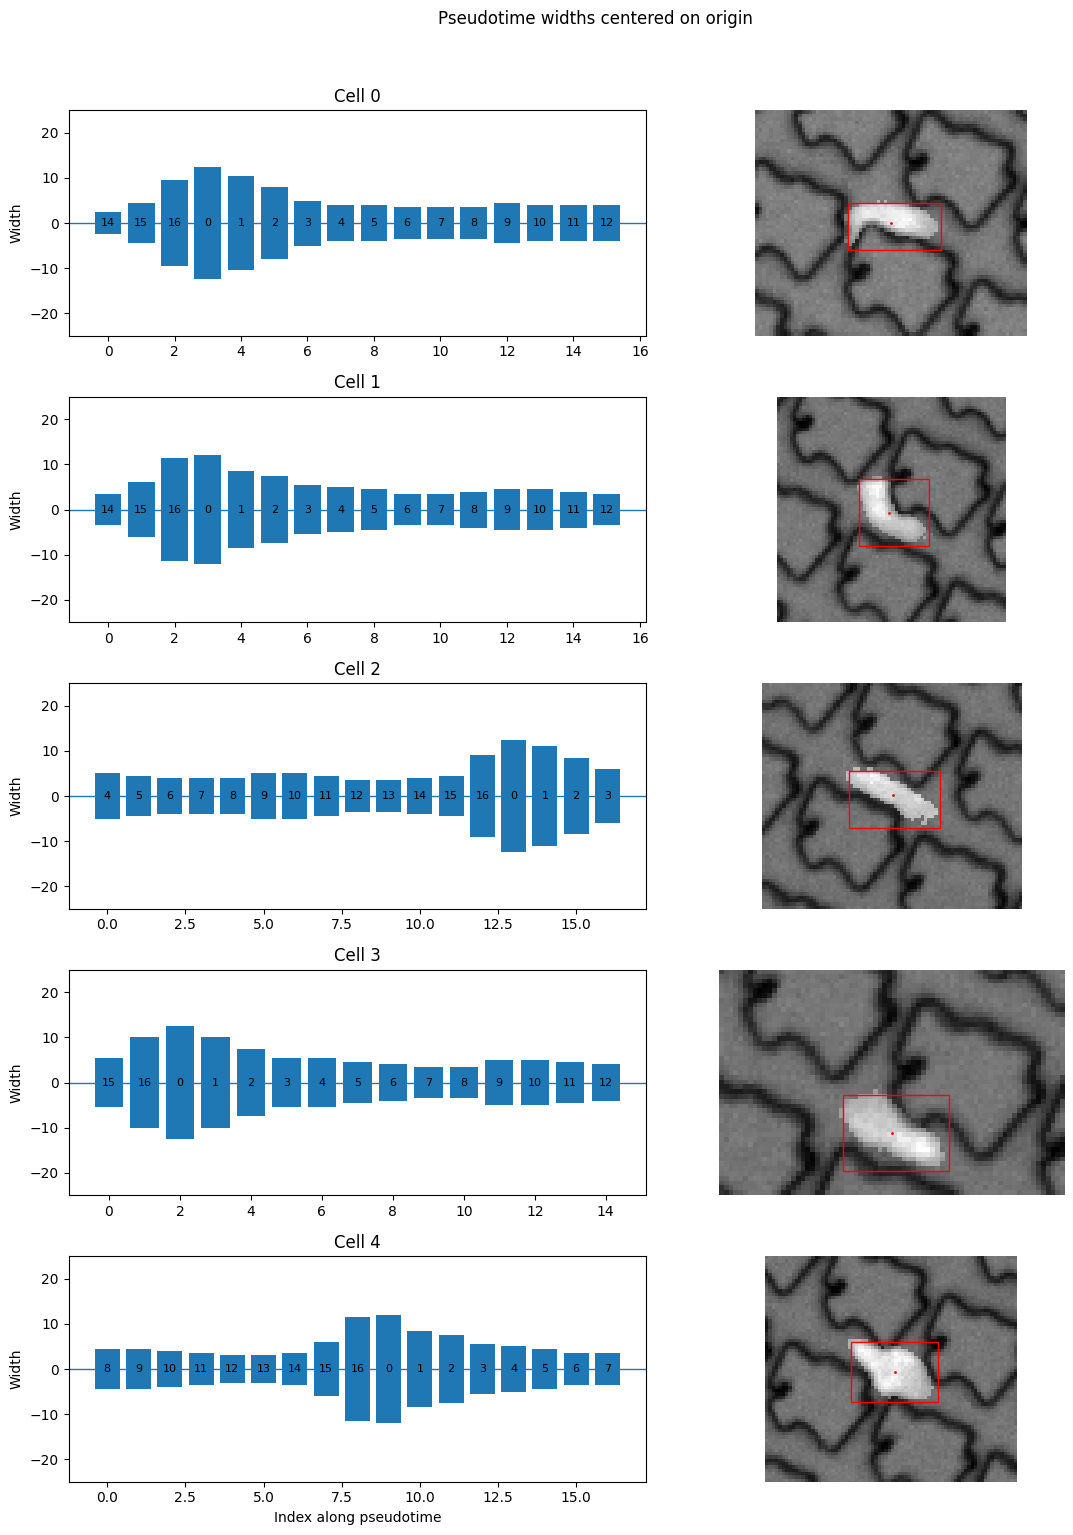

In [14]:
def plot_pseudotime_for_cells(df, num_cells=10):
    num_cells = min(num_cells, len(df))

    fig, axes = plt.subplots(
        max(num_cells, 2), 2,
        figsize=(12, 3 * num_cells),
        sharex=False
    )

    dfs = df.sample(n=num_cells, random_state=42)

    if num_cells == 1:
        axes = np.atleast_1d(axes)

    # global max width for symmetric y-limits
    all_widths = np.concatenate(
        dfs.iloc[:num_cells]["pseudotime_widths"]
        .apply(lambda x: np.array(x, dtype=int))
        .values
    )
    max_width = all_widths.max()

    for i in range(num_cells):
        row = dfs.iloc[i]

        ids = row["pseudotime"]
        widths = np.array(row["pseudotime_widths"], dtype=int)
        x = np.arange(len(widths))

        # center bars at y = 0
        bottoms = -widths / 2

        axes[i, 0].bar(x, widths, bottom=bottoms)
        axes[i, 0].axhline(0, linewidth=1)

        axes[i, 0].set_ylabel("Width")
        axes[i, 0].set_title(f"Cell {i}")
        axes[i, 0].set_ylim(-max_width, max_width)

        # label pseudotime IDs at bar centers (y = 0)
        for xi, label in zip(x, ids):
            axes[i, 0].text(
                xi,
                0,
                str(label),
                ha="center",
                va="center",
                fontsize=8
            )

        img = imread(row["path_dapi"]).astype(float)
        print(row["path_dapi"])
        bg  = imread(row["path_background"]).astype(float)

        H, W = img.shape[:2]
        pad = 25

        cx = row["centered_center_x"] + img.shape[1] // 2
        cy = row["centered_center_y"] + img.shape[0] // 2
        bbox_min_x = row["centered_bbox_min_x"] + img.shape[1] // 2
        bbox_max_x = row["centered_bbox_max_x"] + img.shape[1] // 2
        bbox_min_y = row["centered_bbox_min_y"] + img.shape[0] // 2
        bbox_max_y = row["centered_bbox_max_y"] + img.shape[0] // 2

        x0 = max(int(bbox_min_x) - pad, 0)
        y0 = max(int(bbox_min_y) - pad, 0)

        x1 = min(int(bbox_max_x) + pad, W)
        y1 = min(int(bbox_max_y) + pad, H)

        img = img[y0:y1, x0:x1]
        bg  = bg[y0:y1, x0:x1]



        #Plot center dot and bbox
        axes[i, 1].plot(cx - x0, cy - y0, marker='o', markersize=1, color='red')
        rect = Rectangle(
            (bbox_min_x - x0, bbox_min_y - y0
             ),
            bbox_max_x - bbox_min_x,
            bbox_max_y - bbox_min_y,
            linewidth=1,
            edgecolor='r',
            facecolor='none'
        )
        axes[i, 1].add_patch(rect)

            # normalize if needed

        
        img /= img.max()
        bg  /= bg.max()

        alpha = 0.5
        blended = (1 - alpha) * img + alpha * bg

        axes[i, 1].imshow(blended, cmap="gray")
        axes[i, 1].axis("off")


    axes[-1, 0].set_xlabel("Index along pseudotime")
    fig.suptitle("Pseudotime widths centered on origin", y=1.02)

    plt.tight_layout()
    plt.show()

plot_pseudotime_for_cells(SD.dataframe, num_cells=5)



In [15]:
from scipy.cluster.hierarchy import linkage, fcluster
from tslearn.metrics import cdist_dtw, cdist_soft_dtw

def has_no_nans(ts):
    ts = np.asarray(ts, dtype=float)  # force numeric
    return not np.isnan(ts).any()

mask = SD.dataframe['pseudotime_widths'].apply(has_no_nans)

SD_clean = SD.dataframe.loc[mask].copy()

X = SD_clean['pseudotime_widths'].to_list()

D_dtw = cdist_dtw(X)
D_soft_dtw = cdist_soft_dtw(X, gamma=1)


lengths = np.array([len(ts) for ts in X])
L = np.abs(lengths[:, None] - lengths[None, :])

alpha = 0.3  # controls importance of length
D = D_dtw + alpha * L
D_soft_dtw + alpha * L


Z = linkage(D, method='ward')
Z_soft = linkage(D_soft_dtw, method='ward')


C:\Users\dmitr\AppData\Local\Temp\ipykernel_15856\1908208766.py:27: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(D, method='ward')


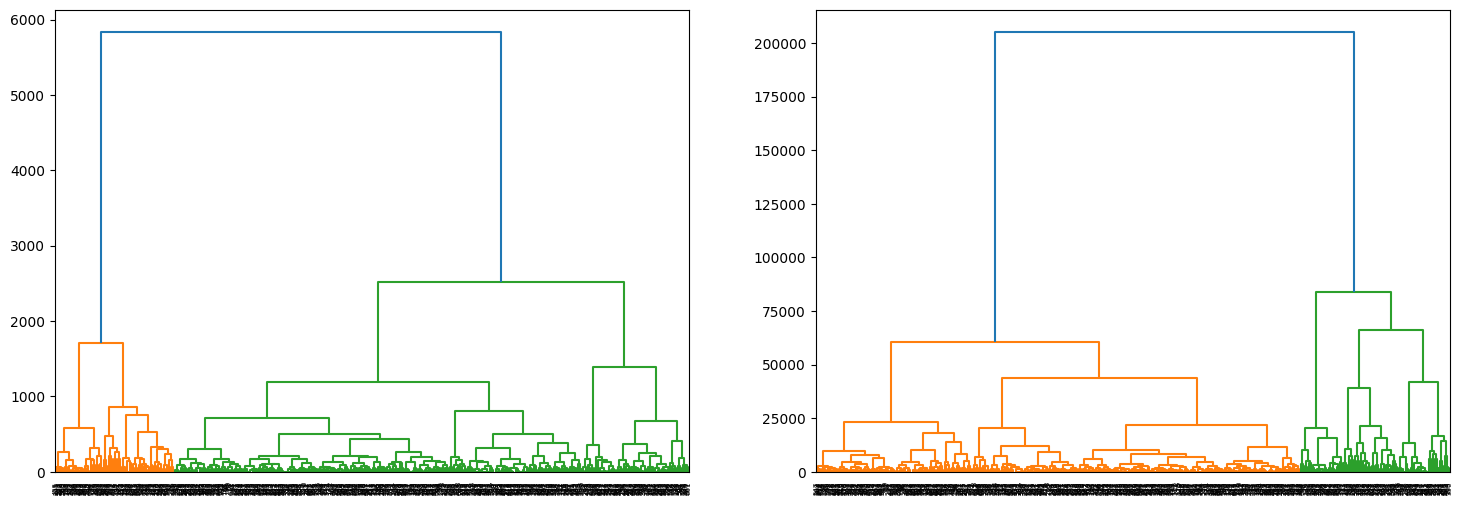

In [16]:
from scipy.cluster.hierarchy import dendrogram

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
dn = dendrogram(Z, ax=axes[0])
dn2 = dendrogram(Z_soft, ax=axes[1])
labels = fcluster(Z, t=5, criterion='maxclust')
soft_labels = fcluster(Z_soft, t=5, criterion='maxclust') 


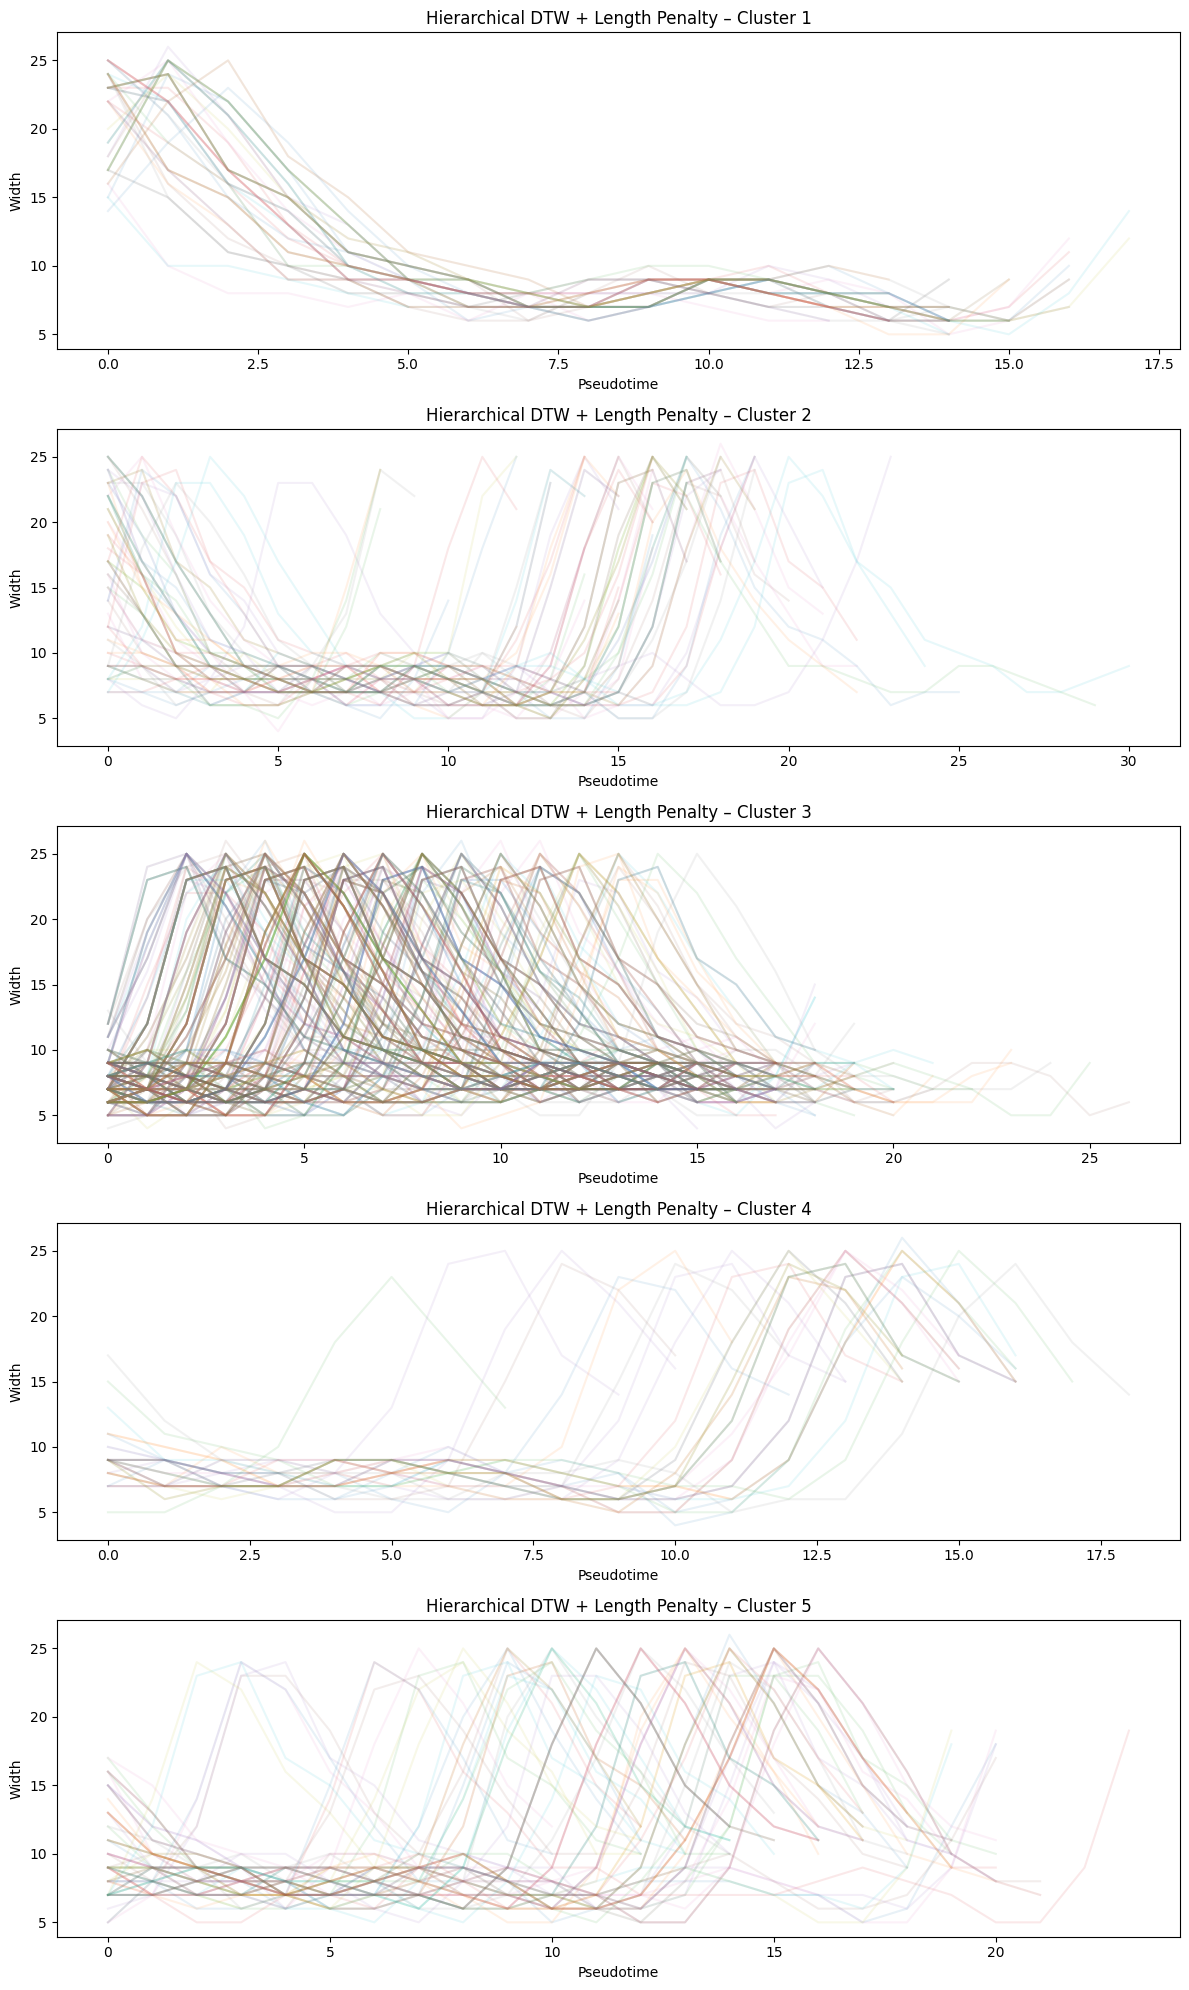

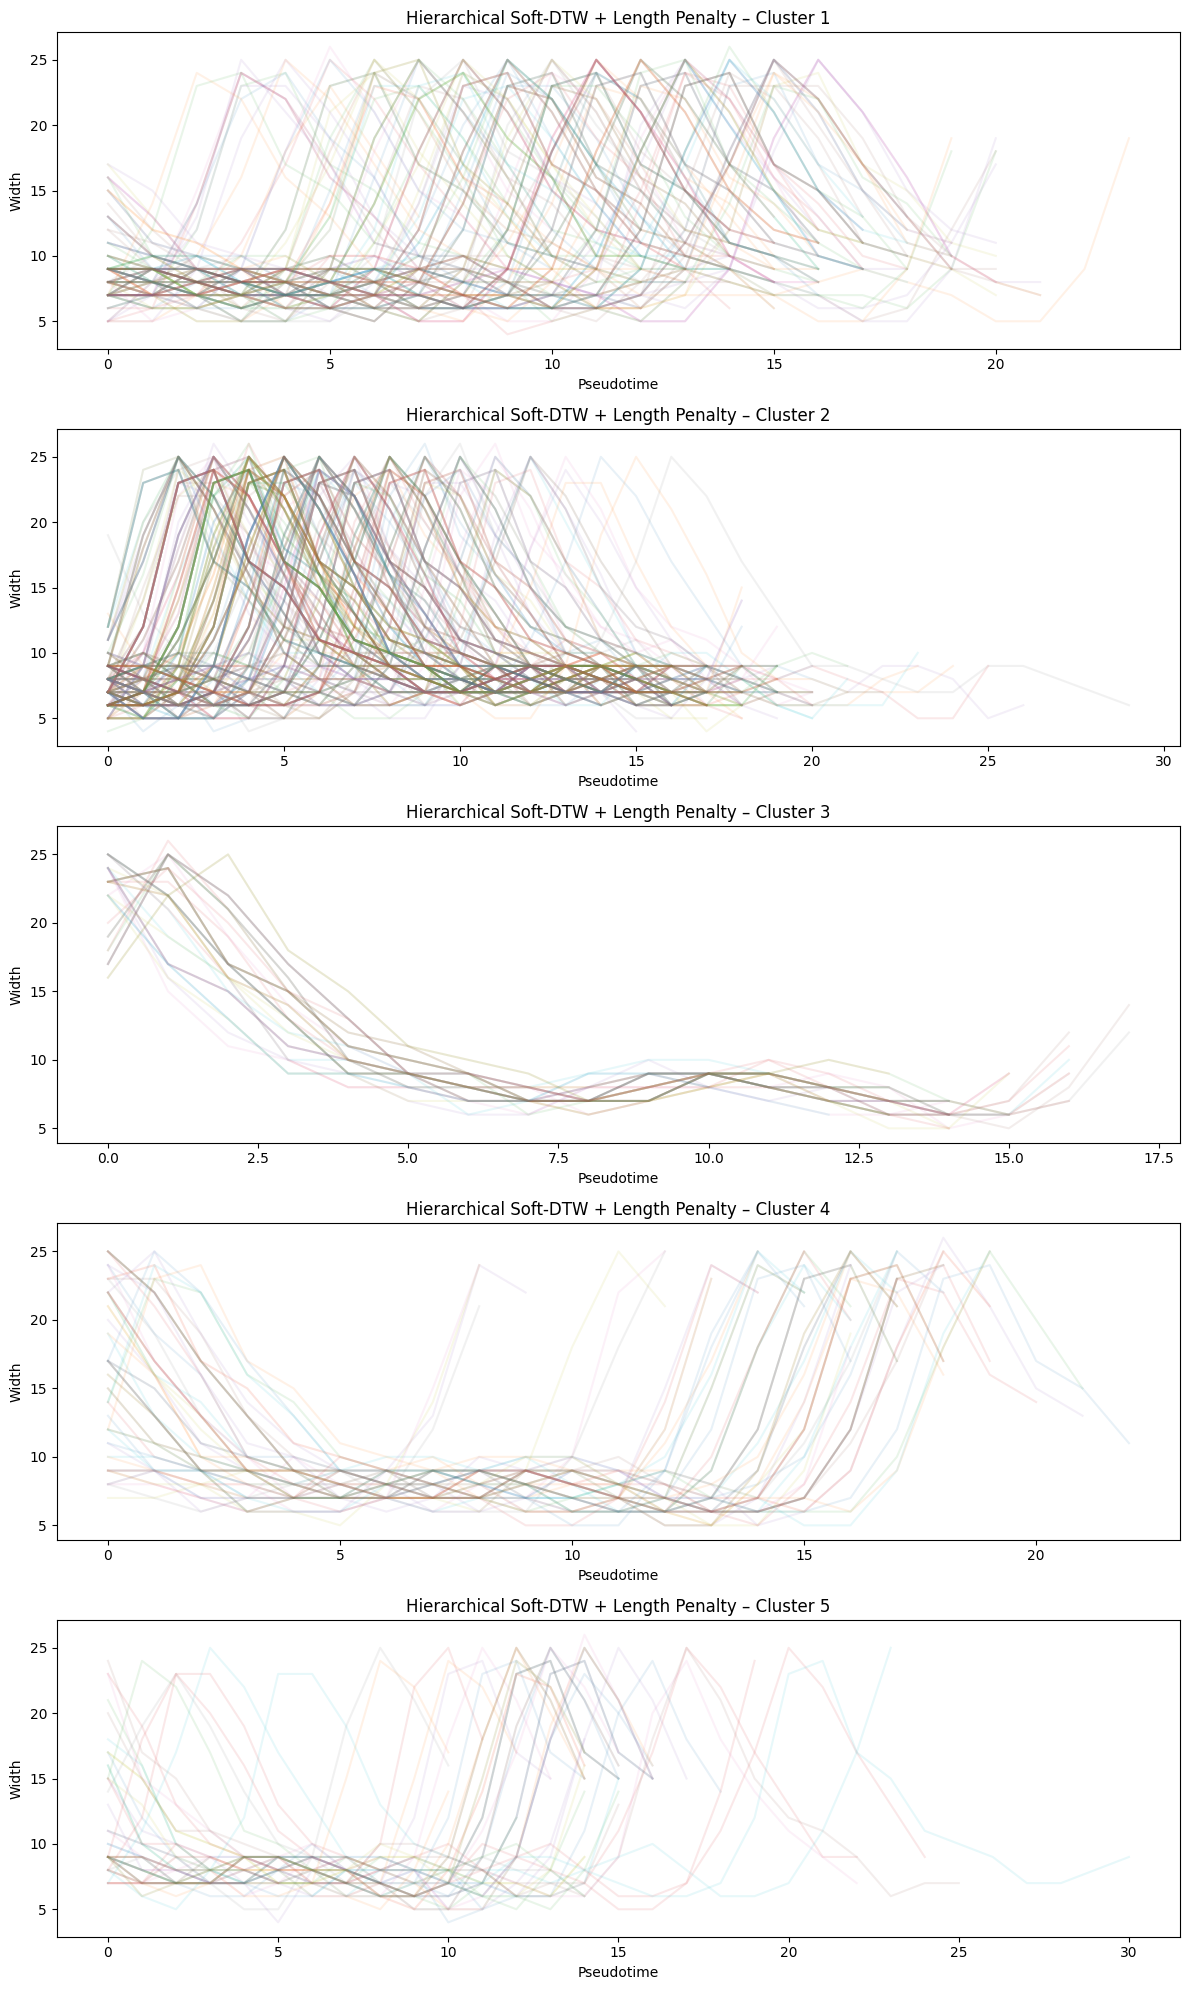

In [17]:
def plot_clusters_variable_length(X, labels, title):
    clusters = np.unique(labels)

    fig, axes = plt.subplots(len(clusters), 1, figsize=(12, 4 * len(clusters)))
    if len(clusters) == 1:
        axes = [axes]

    for ax, c in zip(axes, clusters):
        for ts in [X[i] for i in range(len(X)) if labels[i] == c]:
            ax.plot(ts, alpha=0.1)
        ax.set_title(f"{title} – Cluster {c}")
        ax.set_xlabel("Pseudotime")
        ax.set_ylabel("Width")

    plt.tight_layout()
    plt.show()

plot_clusters_variable_length(
    X,
    labels,
    title="Hierarchical DTW + Length Penalty"
)

plot_clusters_variable_length(
    X,
    soft_labels,
    title="Hierarchical Soft-DTW + Length Penalty"
)

C:\Users\dmitr\AppData\Local\Temp\ipykernel_15856\592840443.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(n, len(x)), random_state=random_state))


C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj5750001_stainDAPI.tif
C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj3200001_stainDAPI.tif
C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj5220001_stainDAPI.tif
C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj2820001_stainDAPI.tif
C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj6520001_stainDAPI.tif


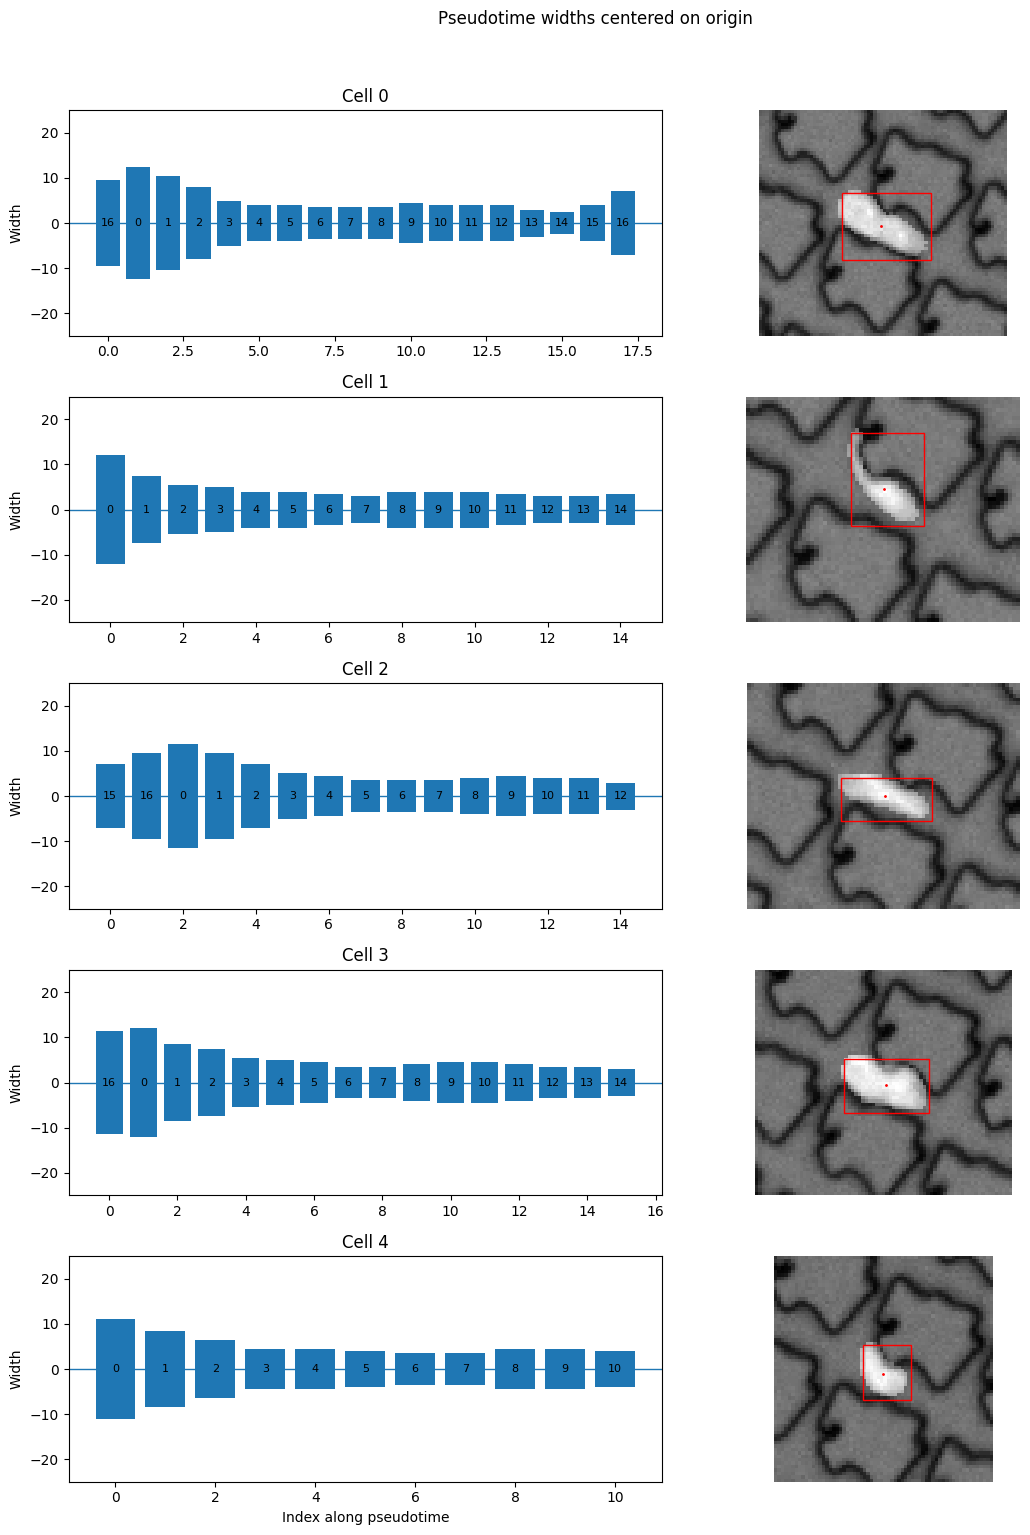

C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj6530001_stainDAPI.tif
C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj3350001_stainDAPI.tif
C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj960001_stainDAPI.tif
C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj300001_stainDAPI.tif
C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj160001_stainDAPI.tif


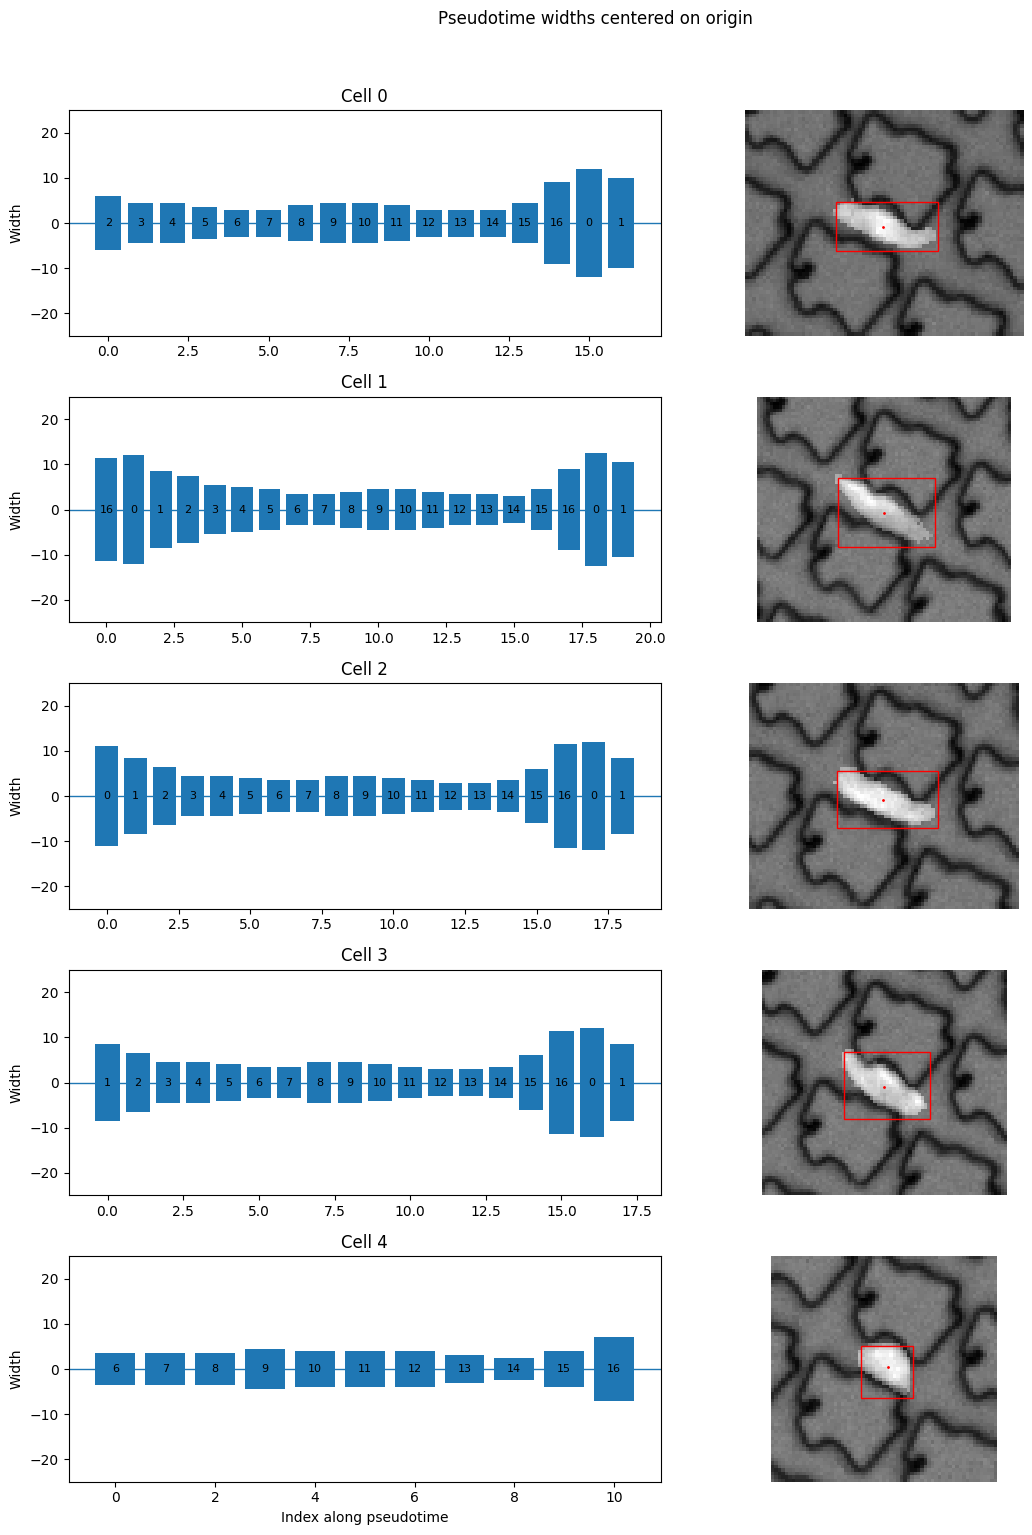

C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj1320001_stainDAPI.tif
C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj6540001_stainDAPI.tif
C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj3120001_stainDAPI.tif
C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj53600010002_stainDAPI.tif
C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj520001_stainDAPI.tif


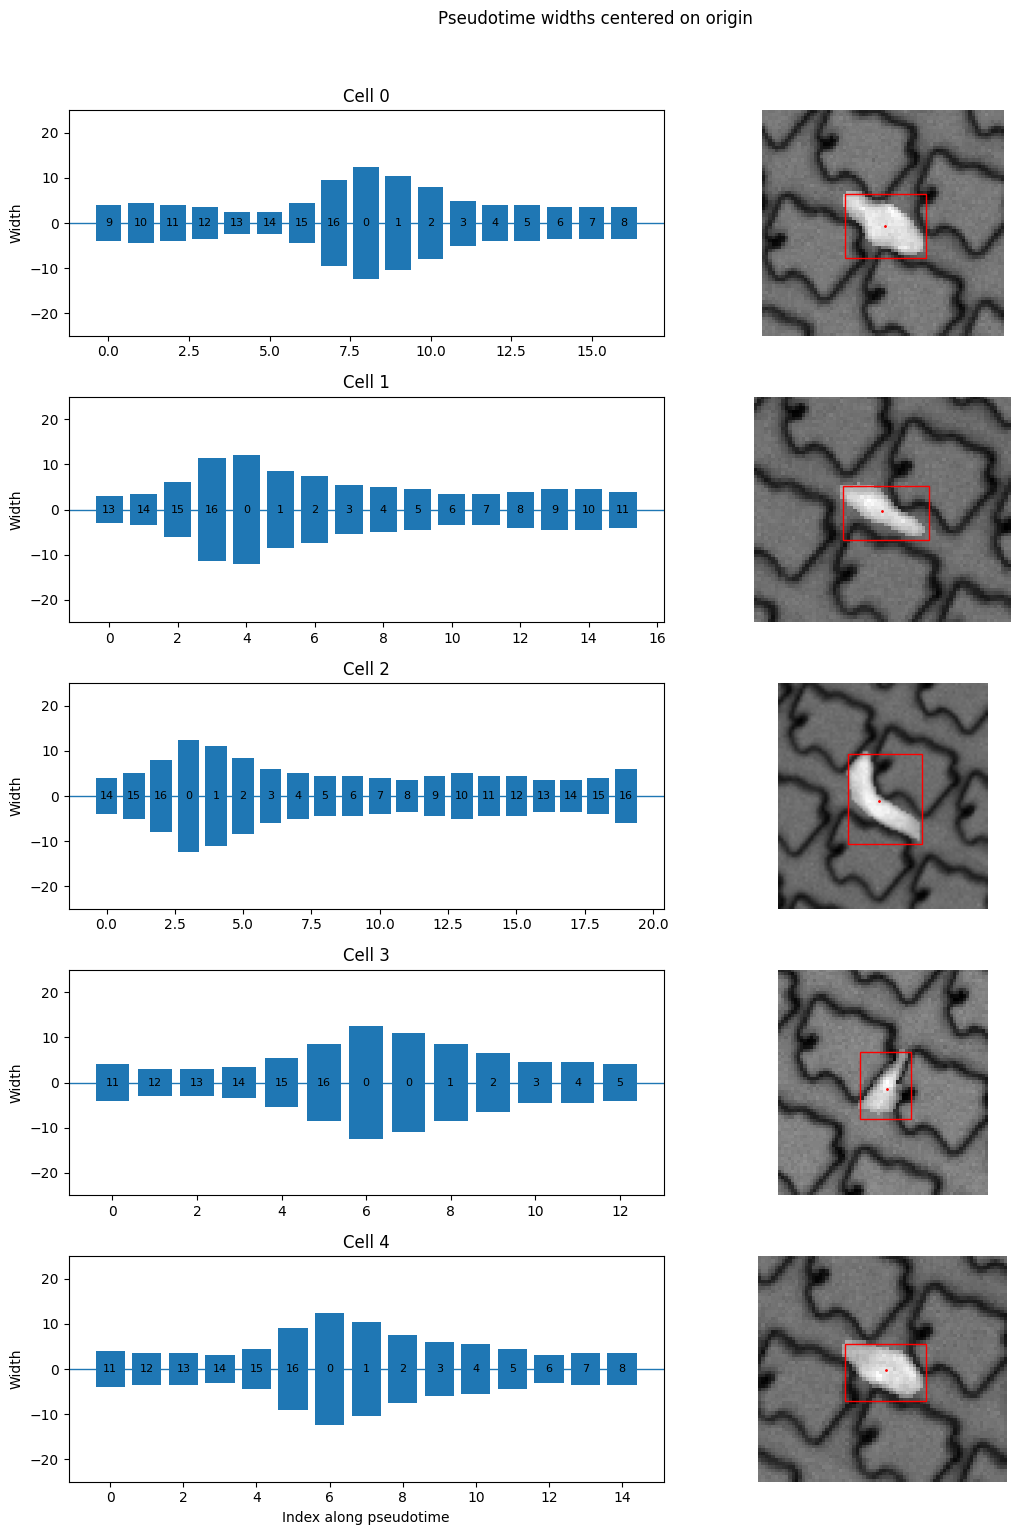

C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj2730001_stainDAPI.tif
C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj3310001_stainDAPI.tif
C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj5130001_stainDAPI.tif
C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj37700010002_stainDAPI.tif
C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj6510001_stainDAPI.tif


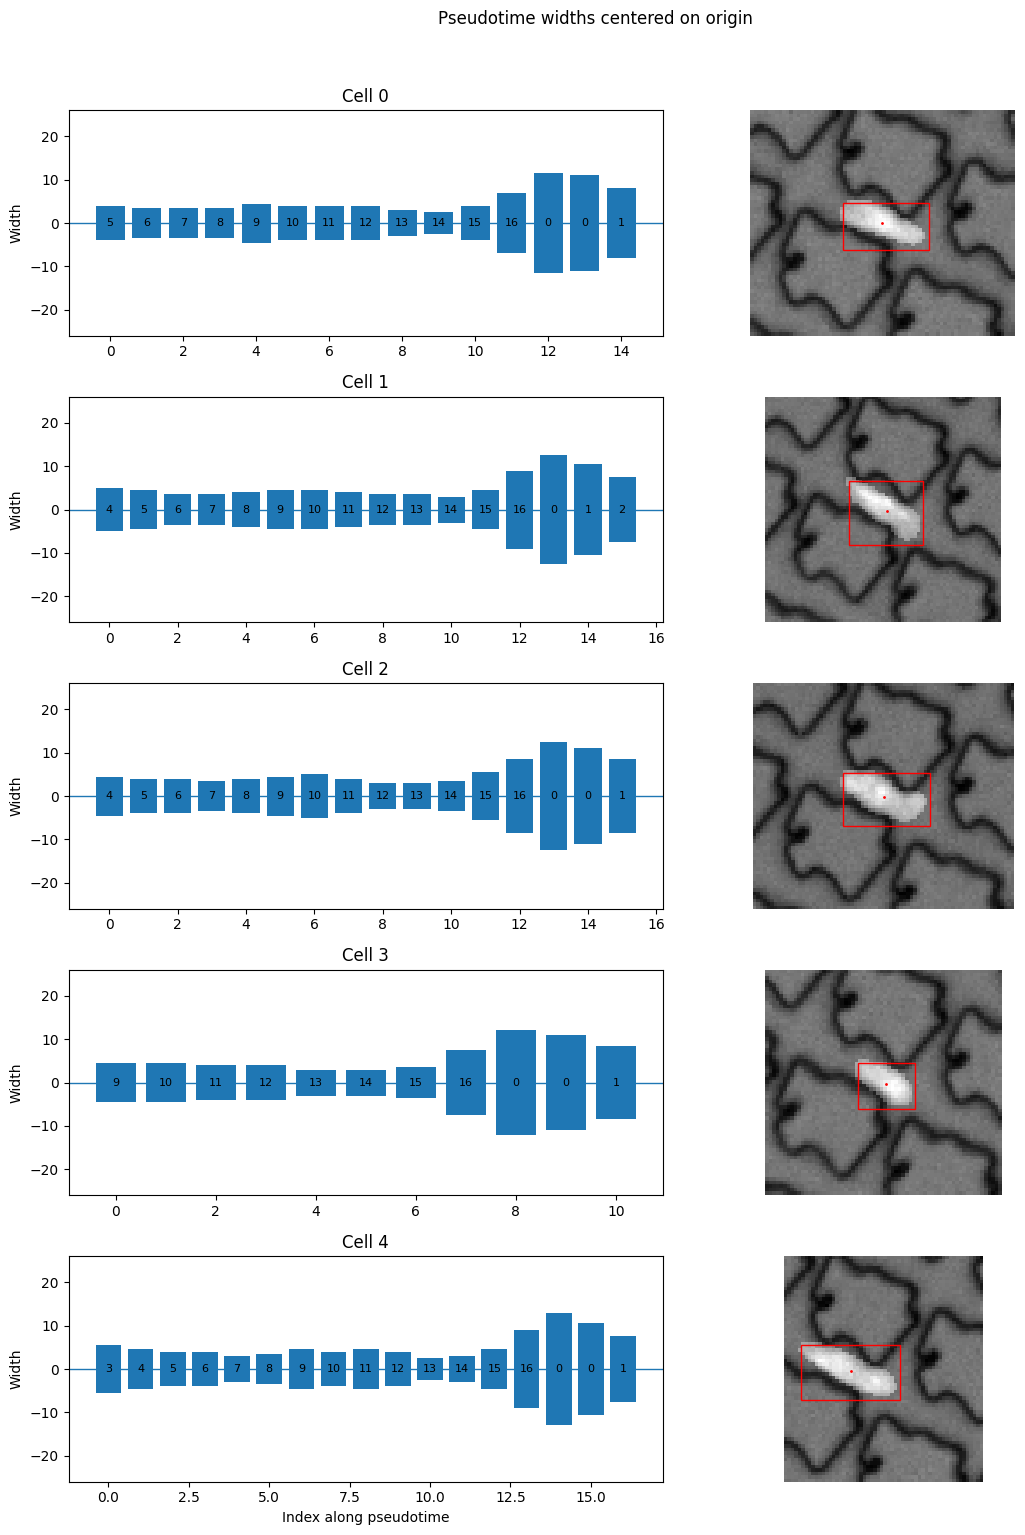

C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj4170001_stainDAPI.tif
C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj5100001_stainDAPI.tif
C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj1040001_stainDAPI.tif
C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj720001_stainDAPI.tif
C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj320001_stainDAPI.tif


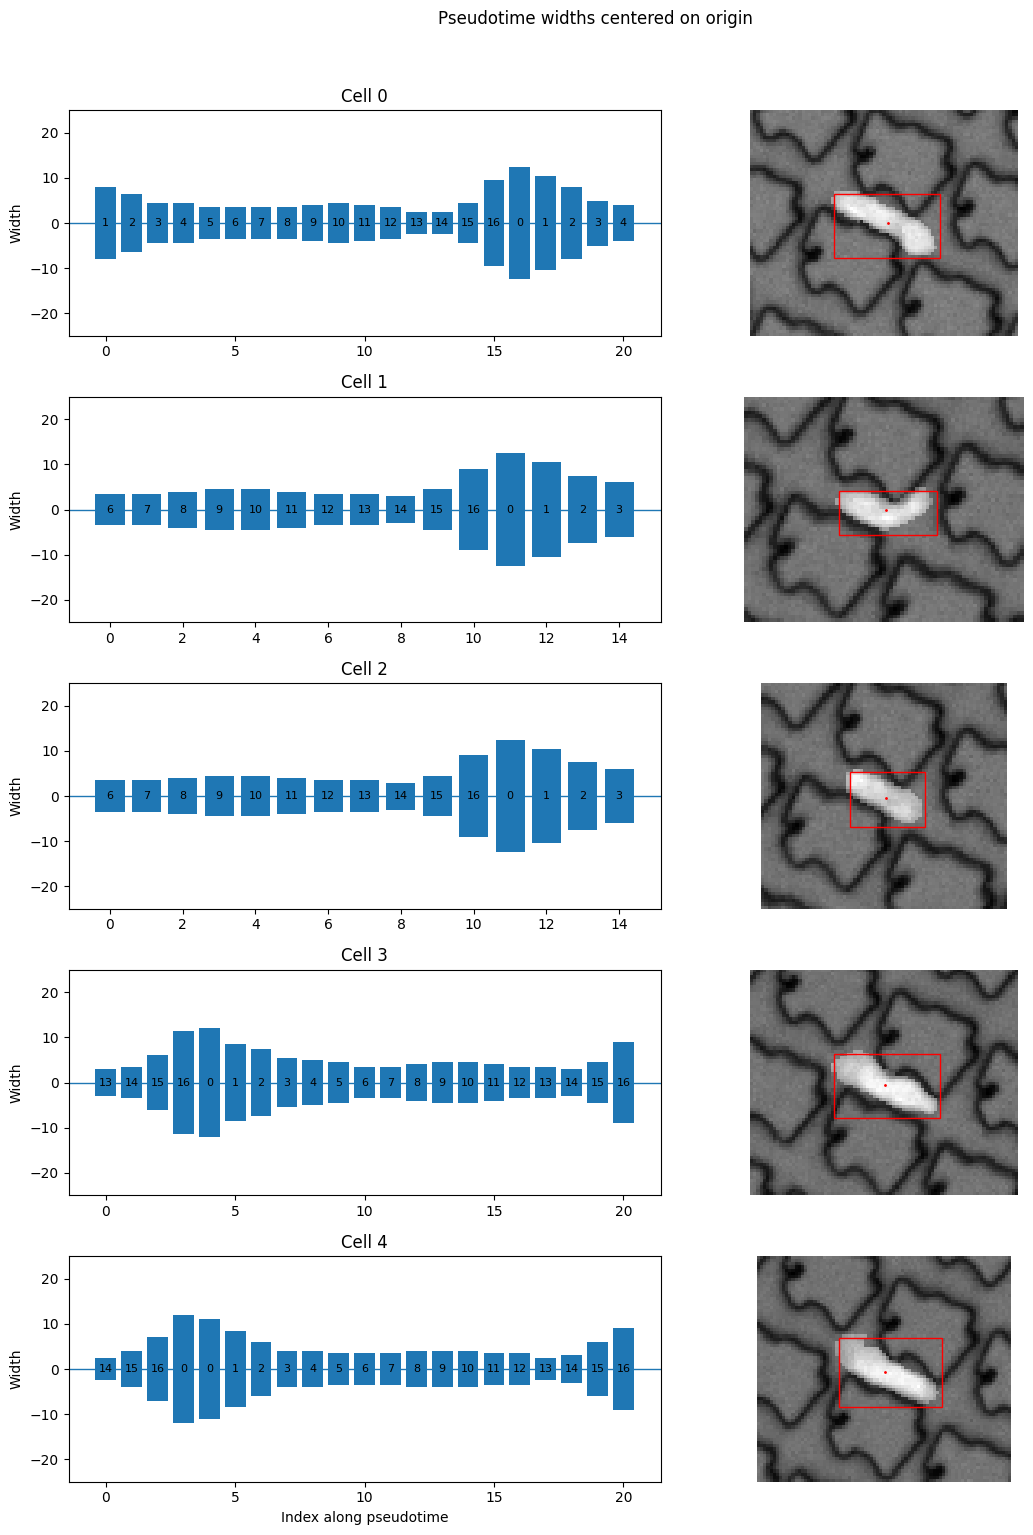

In [18]:
def sample_rows_per_cluster(df, cluster_col, n=5, random_state=42):
    return (
        df
        .groupby(cluster_col, group_keys=False)
        .apply(lambda x: x.sample(min(n, len(x)), random_state=random_state))
    )

SD_clean['cluster_hier'] = labels

df_hier_samples = sample_rows_per_cluster(
    SD_clean,
    cluster_col='cluster_hier',
    n=5
)

plot_pseudotime_for_cells(df_hier_samples.query('cluster_hier == 1'), num_cells=5)
plot_pseudotime_for_cells(df_hier_samples.query('cluster_hier == 2'), num_cells=5)
plot_pseudotime_for_cells(df_hier_samples.query('cluster_hier == 3'), num_cells=5)
plot_pseudotime_for_cells(df_hier_samples.query('cluster_hier == 4'), num_cells=5)
plot_pseudotime_for_cells(df_hier_samples.query('cluster_hier == 5'), num_cells=5)

In [19]:
from sklearn.cluster import KMeans


features = [
    [
        np.mean(ts),
        np.std(ts),
        np.max(ts),
        np.min(ts),
        len(ts)
    ]
    for ts in X
]

kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(features)


,n_clusters,2
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


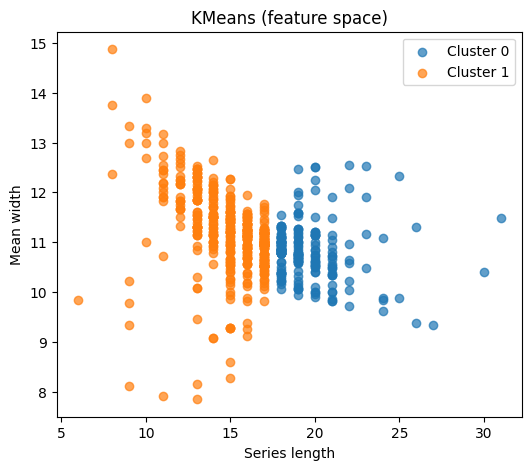

In [20]:
labels_kmeans = kmeans.labels_

features = np.array(features)

plt.figure(figsize=(6, 5))
for c in np.unique(labels_kmeans):
    idx = labels_kmeans == c
    plt.scatter(
        features[idx, -1],     # length
        features[idx, 0],      # mean
        label=f"Cluster {c}",
        alpha=0.7
    )

plt.xlabel("Series length")
plt.ylabel("Mean width")
plt.title("KMeans (feature space)")
plt.legend()
plt.show()

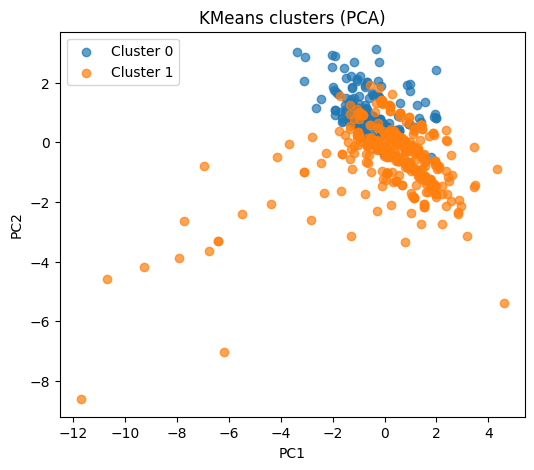

In [21]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(features)
X_pca = PCA(n_components=2).fit_transform(X_scaled)

plt.figure(figsize=(6, 5))
for c in np.unique(labels_kmeans):
    idx = labels_kmeans == c
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=f"Cluster {c}", alpha=0.7)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans clusters (PCA)")
plt.legend()
plt.show()

C:\Users\dmitr\AppData\Local\Temp\ipykernel_15856\592840443.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(n, len(x)), random_state=random_state))


C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj7150001_stainDAPI.tif
C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj3520001_stainDAPI.tif
C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj1790001_stainDAPI.tif
C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj300001_stainDAPI.tif
C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj6990001_stainDAPI.tif


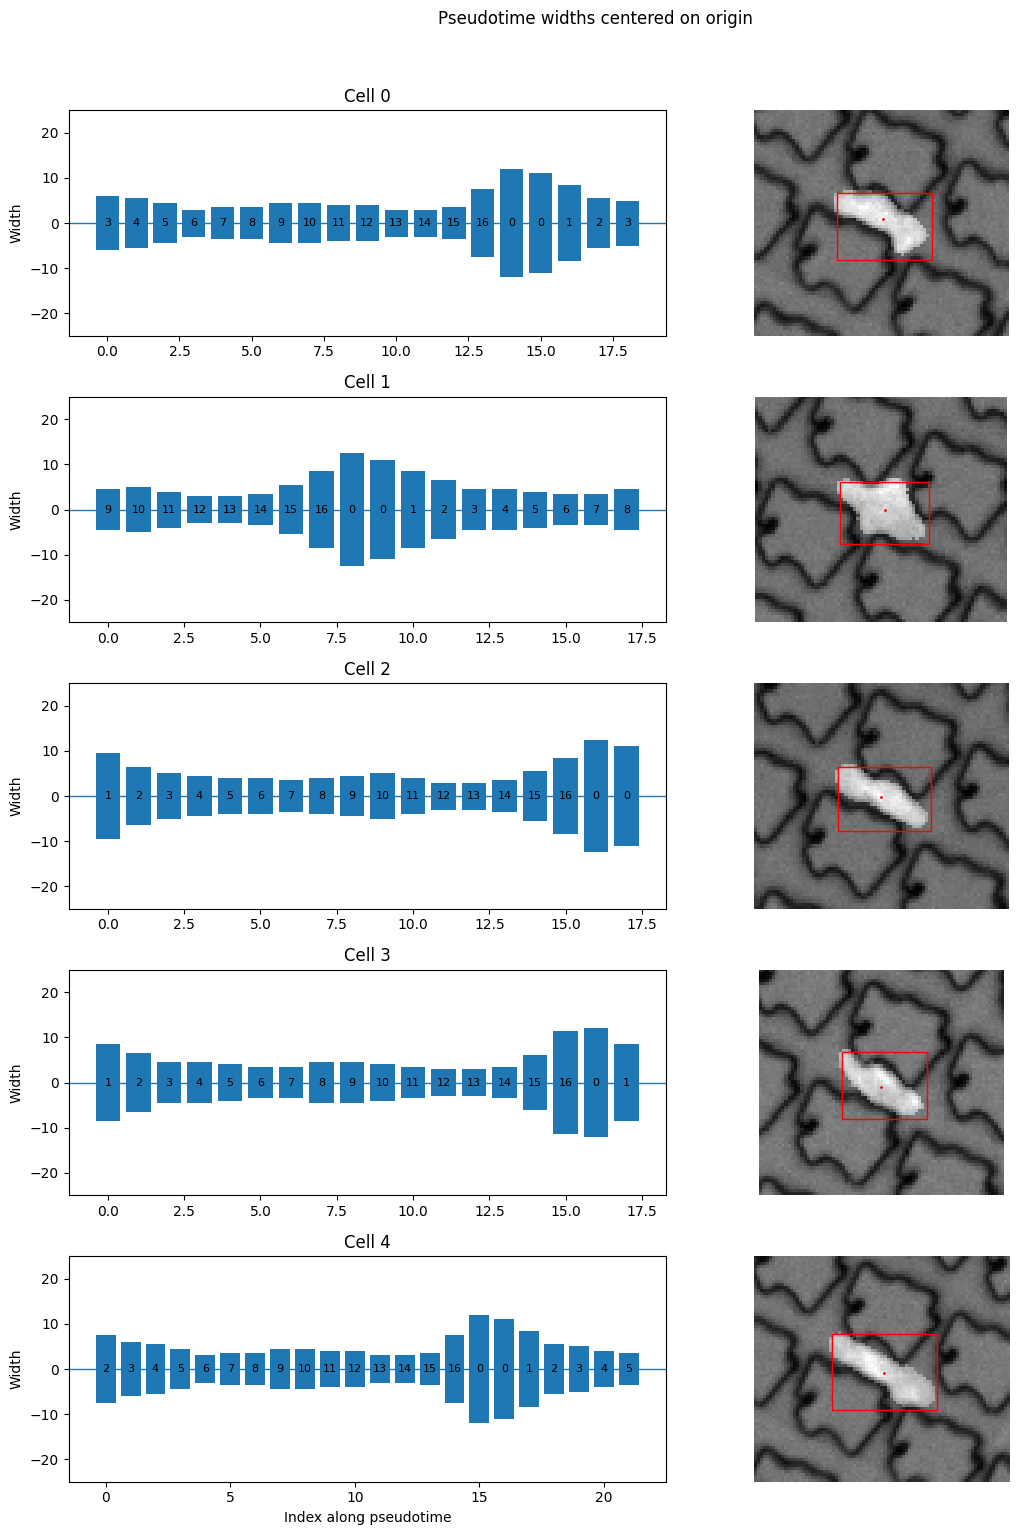

C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj660001_stainDAPI.tif
C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj2840001_stainDAPI.tif
C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj5730001_stainDAPI.tif
C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj5240001_stainDAPI.tif
C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj5670001_stainDAPI.tif


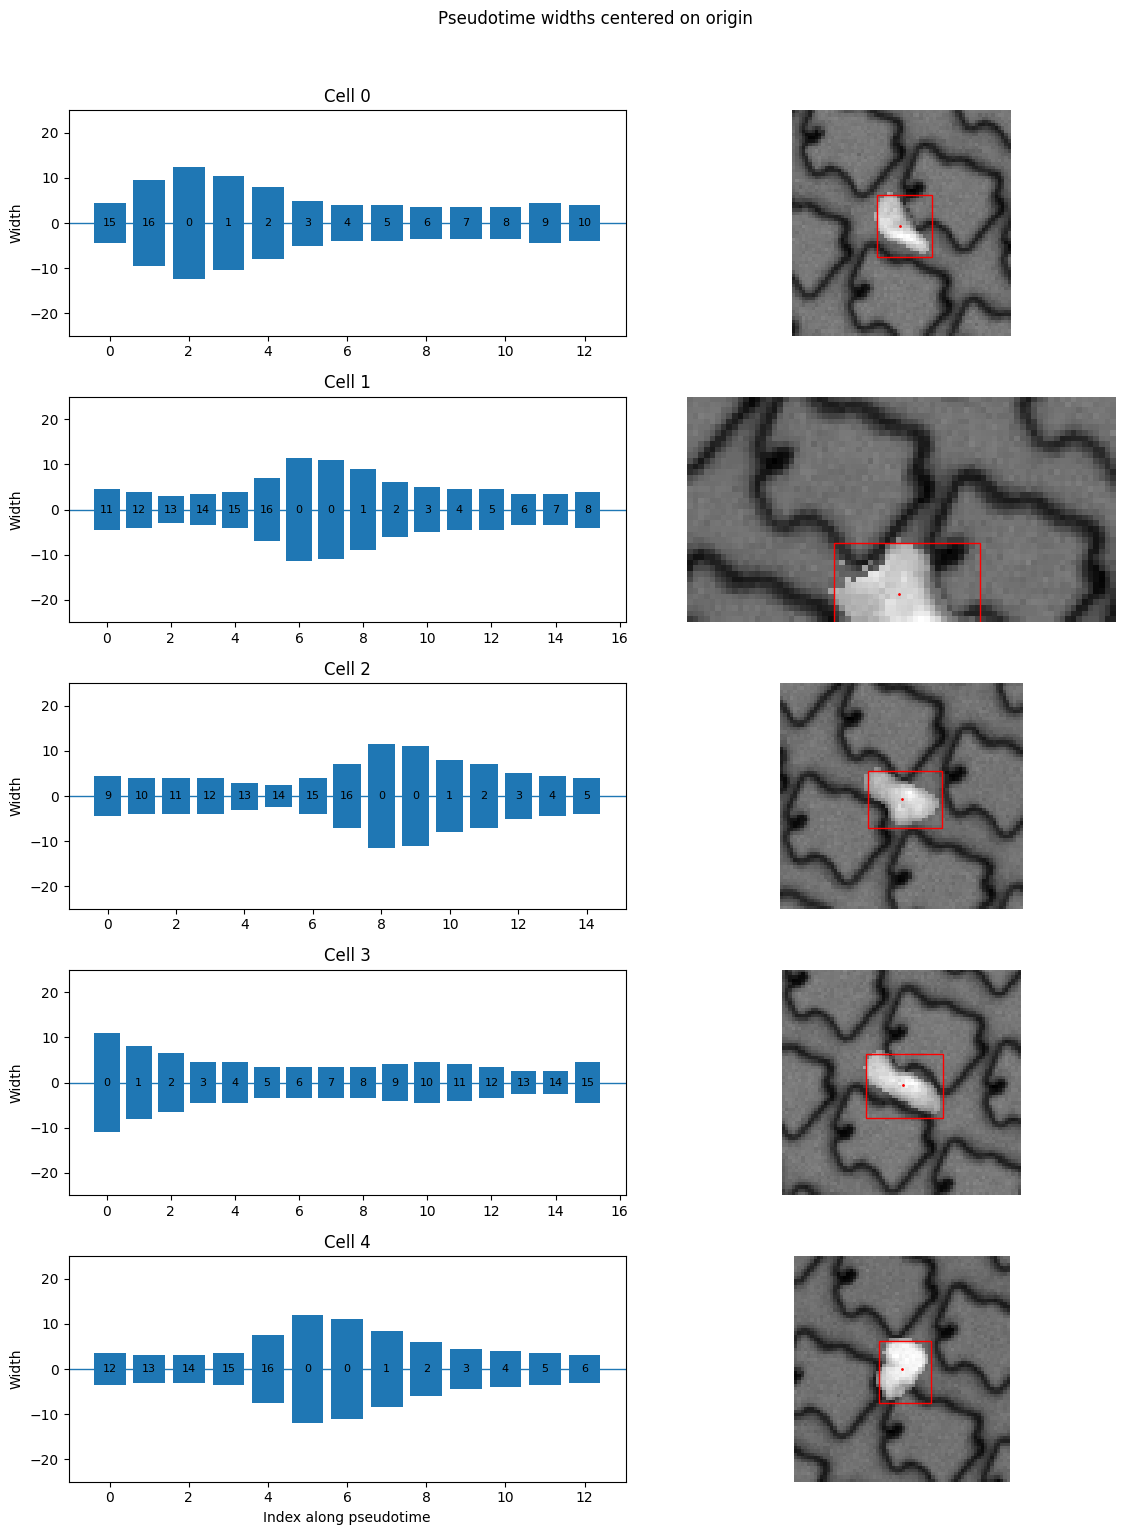

,path_background,path_dapi,path_yap,path_actin,height,width,channels,radial_distribution.RadialDistribution_FracAtD_1of4,radial_distribution.RadialDistribution_MeanFrac_1of4,radial_distribution.RadialDistribution_RadialCV_1of4,...,centered_bbox_max_x,centered_bbox_max_y,bbox_rot_min_x,bbox_rot_min_y,bbox_rot_max_x,bbox_rot_max_y,pseudotime,pseudotime_widths,cluster_hier,cluster_kmeans
obj_id,,,,,,,,,,,,,,,,,,,,,
5240001,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.438247,14.274331,0.402323,...,0.5,-23.5,-41.333286,-38.523501,-10.715658,-9.527591,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[22, 16, 13, 9, 9, 7, 7, 7, 7, 8, 9, 8, 7, 5, ...",1,1
660001,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.177388,4.966862,0.456975,...,22.5,-12.5,-10.112647,-38.405467,13.869280,-13.612681,"[15, 16, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[9, 19, 25, 21, 16, 10, 8, 8, 7, 7, 7, 9, 8]",3,1
5730001,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.055877,1.347249,0.589623,...,43.5,-0.5,10.615579,-36.052438,38.048789,-10.646376,"[9, 10, 11, 12, 13, 14, 15, 16, 0, 0, 1, 2, 3,...","[9, 8, 8, 8, 6, 5, 8, 14, 23, 22, 16, 14, 10, ...",3,1
5670001,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.185185,4.279835,0.380613,...,28.5,-41.5,-17.718302,-66.777835,5.383483,-42.459761,"[12, 13, 14, 15, 16, 0, 0, 1, 2, 3, 4, 5, 6]","[7, 6, 6, 7, 15, 24, 22, 17, 12, 9, 8, 7, 6]",3,1
2840001,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.368421,7.478947,0.491879,...,-29.5,150.5,15.475618,133.263141,45.479969,158.807769,"[11, 12, 13, 14, 15, 16, 0, 0, 1, 2, 3, 4, 5, ...","[9, 8, 6, 7, 8, 14, 23, 22, 18, 12, 10, 9, 9, ...",3,1


In [22]:
SD_clean['cluster_kmeans'] = labels_kmeans

df_kmeans_samples = sample_rows_per_cluster(
    SD_clean,
    cluster_col='cluster_kmeans',
    n=5
)

df_kmeans_samples

plot_pseudotime_for_cells(df_kmeans_samples.query('cluster_kmeans == 0'), num_cells=5)
plot_pseudotime_for_cells(df_kmeans_samples.query('cluster_kmeans == 1'), num_cells=5)
df_kmeans_samples.query('cluster_kmeans == 1')

In [105]:
SD_clean

,path_background,path_dapi,path_yap,path_actin,height,width,channels,radial_distribution.RadialDistribution_FracAtD_1of4,radial_distribution.RadialDistribution_MeanFrac_1of4,radial_distribution.RadialDistribution_RadialCV_1of4,...,centered_bbox_max_x,centered_bbox_max_y,bbox_rot_min_x,bbox_rot_min_y,bbox_rot_max_x,bbox_rot_max_y,pseudotime,pseudotime_widths,cluster_hier,cluster_kmeans
obj_id,,,,,,,,,,,,,,,,,,,,,
10001,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.320611,8.603053,0.293314,...,-7.5,-28.5,-54.673970,-38.246371,-20.130348,-7.757043,"[11, 12, 13, 14, 15, 16, 0, 0, 1, 2, 3, 4, 5, ...","[8, 7, 5, 5, 7, 14, 24, 22, 16, 13, 9, 9, 7, 7...",3,0
20001,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.272553,5.027085,0.366094,...,-19.5,-28.5,-50.609410,-29.909405,-30.692043,-9.181178,"[13, 14, 15, 16, 0, 0, 1, 2, 3, 4, 5]","[5, 5, 7, 14, 24, 22, 16, 13, 9, 9, 7]",3,1
30001,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.171021,5.244656,0.419590,...,-29.5,74.5,-23.797167,52.290145,9.401867,89.543473,"[9, 10, 11, 12, 13, 14, 15, 16, 0, 0, 1, 2, 3,...","[9, 9, 8, 8, 7, 6, 9, 19, 25, 22, 17, 12, 11, ...",3,0
40001,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.165913,4.848332,0.433454,...,-25.5,81.5,-13.017359,67.113982,16.245415,94.755039,"[14, 15, 16, 0, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, ...","[6, 9, 19, 25, 22, 17, 12, 11, 9, 9, 7, 7, 9, ...",3,0
50001,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.519174,12.748607,0.539141,...,52.5,4.5,22.265263,-35.043998,48.343620,-10.992788,"[15, 16, 0, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[8, 14, 23, 22, 16, 14, 10, 9, 8, 7, 6, 7, 8, 9]",3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
453000100020003,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.161863,3.329743,0.439287,...,62.5,49.5,56.018558,1.575523,78.507066,22.442314,"[14, 15, 16, 0, 0, 1, 2, 3, 4, 5, 6, 7]","[6, 7, 15, 24, 22, 17, 11, 10, 8, 7, 6, 7]",3,1
457000100020003,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.016863,0.215008,0.027109,...,-142.5,135.5,-72.004779,178.104170,-61.096672,190.228565,"[2, 3, 4, 5, 6, 7]","[15, 10, 10, 9, 8, 7]",1,1
470000100020003,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.164207,6.207011,0.055189,...,-57.5,104.5,-32.834648,104.308293,-1.000732,132.087915,"[4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16,...","[10, 9, 8, 8, 8, 10, 10, 9, 7, 7, 8, 9, 18, 25...",5,0
